Using Colab cache for faster access to the 'home-credit' dataset.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


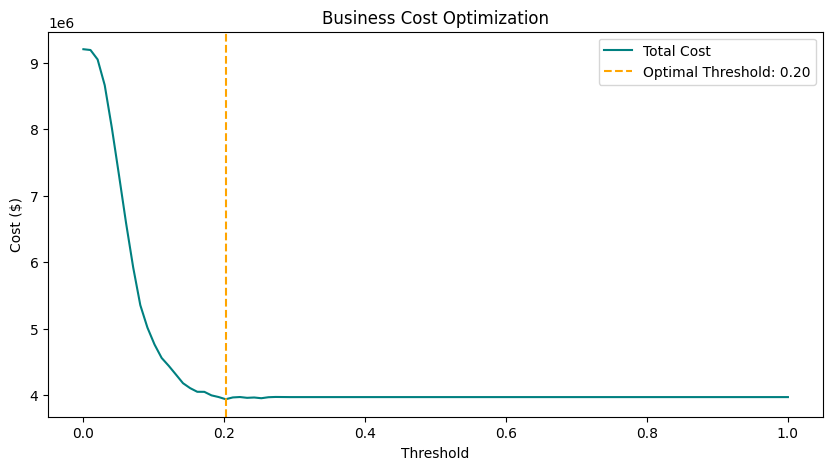

Optimal Threshold: 0.20
Minimum Estimated Business Cost: $3,938,000.00
ROC-AUC Score: 0.6217


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
import glob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score

# 1. DOWNLOAD AND LOCATE DATASET
path = kagglehub.dataset_download("anggundwilestari/home-credit")
# Using the path found in your previous error log
data_path = "/kaggle/input/home-credit/HC_application_train.csv"

# 2. LOAD AND CLEAN
# Loading a sample for speed
df = pd.read_csv(data_path).sample(50000, random_state=42)

# Strictly isolate numeric columns to prevent the Median TypeError
df_numeric = df.select_dtypes(include=[np.number])

# Fill missing values with the median of each numeric column
df_numeric = df_numeric.fillna(df_numeric.median())

X = df_numeric.drop('TARGET', axis=1)
y = df_numeric['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAIN CLASSIFICATION MODEL [cite: 60]
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)[:, 1]

# 4. BUSINESS COST OPTIMIZATION [cite: 56, 61, 62]
# Cost of False Positive (FP) and False Negative (FN) [cite: 61]
cost_fp = 1000
cost_fn = 5000

thresholds = np.linspace(0, 1, 100)
costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        costs.append((fp * cost_fp) + (fn * cost_fn))
    else:
        costs.append(np.inf)

# Find the threshold that minimizes total business cost [cite: 62]
optimal_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

# 5. VISUALIZATION [cite: 62]
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='teal', label='Total Cost')
plt.axvline(optimal_threshold, color='orange', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.title('Business Cost Optimization')
plt.xlabel('Threshold')
plt.ylabel('Cost ($)')
plt.legend()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Estimated Business Cost: ${min_cost:,.2f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")